# Goals

* Focusing on the GT collection, SKU level modeling
* models are on the OLS, GBM
* What-if analyis on multiple scenarios


# Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid
import statsmodels.formula.api as smf

# Data Wrangling

In [3]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"]="/Users/wphong/Desktop/Zinus/market-analysis-project-91130-f7b373249865.json"

import google.auth 

from google.cloud import bigquery

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [4]:
sql = """
select * from wook.fact_amz_mkt_all;
"""
# select zinus_sku_cd as sku, collection from `market-analysis-project-91130.meta.erp_sku_collection_220330`

df = bqclient.query(sql).to_dataframe()
df = df.drop_duplicates()
df

,asin,prdct_title,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,zinus_sku,collection,profile,size,yr_wk,rvw_cnt,star12_cnt,star12_ratio
0,B088N8J71Y,Beige Swatch,0.00,24,<NA>,0.000000,4,6.000000,0.000000,FSLTD-BG,None,None,None,202024,<NA>,<NA>,NaN
1,B088NP3K7P,Soft Grey Swatch,0.00,2,<NA>,0.000000,2,1.000000,0.000000,FB5432G,None,None,None,202029,<NA>,<NA>,NaN
2,B07HYVX2NZ,"Zinus Alto Table, White",220.58,1,436,220.580000,39,0.025641,0.000000,OLB-DT-AW47,OLB DT,None,None,202052,<NA>,<NA>,NaN
3,B07GGF5RFF,"Zinus Josh, Sofa, Beige",8331.46,25,72,333.258400,10703,0.002336,0.000000,SSTD-BG,SSTD,None,None,202030,4,2,0.5
4,B07GGF5RFF,"Zinus Josh, Sofa, Beige",25999.62,81,69,320.982963,15518,0.005220,0.000000,SSTD-BG,SSTD,None,None,202029,4,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174094,B07W8JQ5KR,Zinus Jared 14 Inch Metal Adjustable Bed Frame...,0.00,0,2160,NaN,237,0.000000,0.040486,ADB-14Q,ADB,14 Inch,Queen,202126,<NA>,<NA>,NaN
174095,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,0.00,0,145,NaN,47,0.000000,0.078431,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202144,<NA>,<NA>,NaN
174096,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,5.08,0,363,NaN,277,0.000000,0.051370,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202150,<NA>,<NA>,NaN
174097,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,0.00,0,308,NaN,176,0.000000,0.078534,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202204,<NA>,<NA>,NaN


## datetime handling

In [5]:
df['year_week']=[pd.to_datetime(str(yr_wk)+'0',format="%Y%U%w") for yr_wk in df.yr_wk]
df.drop('yr_wk',axis=1,inplace=True)
df.sort_values(by=['year_week','profile'],inplace=True)

In [6]:
df.reset_index(drop=True,inplace=True)

## Range of date

from Jan. 2020 to Jun. 2022

In [7]:
np.min(df.year_week),np.max(df.year_week)

(Timestamp('2020-01-05 00:00:00'), Timestamp('2022-06-12 00:00:00'))

how many weeks if full records? ==> $128$ points

In [8]:
pd.date_range(start='2020-01-05',end='2022-06-12',freq='W')

DatetimeIndex(['2020-01-05', '2020-01-12', '2020-01-19', '2020-01-26',
               '2020-02-02', '2020-02-09', '2020-02-16', '2020-02-23',
               '2020-03-01', '2020-03-08',
               ...
               '2022-04-10', '2022-04-17', '2022-04-24', '2022-05-01',
               '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29',
               '2022-06-05', '2022-06-12'],
              dtype='datetime64[ns]', length=128, freq='W-SUN')

## Remove rows with no collection info

In [9]:
df = df[~df.collection.isna()]

In [10]:
df.shape

(163724, 17)

## Subsetting on the Green Tea product

In [11]:
# Check if prodcut title contains Green & Tea & Matress
flags = [(len(set(['Green','Tea','Mattress']).intersection(set(prdct.split()))) ==3) \
     for prdct in df.prdct_title]
sum(flags)

10756

In [12]:
df[flags].prdct_title.unique().shape

(187,)

In [13]:
flags2 = [not ((prdct.__contains__('Pad')) | (prdct.__contains__('Topper'))) for prdct in df[flags].prdct_title]
sum(flags2)

5379

In [14]:
df_gt = df[flags][flags2].copy()
df_gt.prdct_title.unique()

array(['Zinus 10 Inch Green Tea Memory Foam Mattress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving, Full',
       'Zinus 10 Inch Green Tea Memory Foam Mattress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving, King',
       'Zinus 10 Inch Green Tea Memory Foam Mattress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving, Twin',
       'Zinus 10 Inch Green Tea Memory Foam Mattress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving, Queen',
       'Zinus 10 Inch Gel-Infused Green Tea Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box, Full',
       'Zinus 10 Inch Gel-Infused Green Tea Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box, King',
       'Zinus 10 Inch Gel-Infused Green Tea Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box, Queen',
       'Zinus 12 Inch Green Tea Memory Foam Mattress / Cer

## Sample counts

In [15]:
vc_asin = df_gt[['collection','asin']].value_counts()
vc_asin

collection  asin      
OLB FGM     B01NANZ5WG    128
            B01NH0QVM4    128
            B01NBPG153    128
            B01NBPG0LU    128
            B01NH0XWNU    128
            B01NH11UG3    128
            B01NANZ3HQ    128
            B01N1X5K70    128
            B01N0VNL1N    128
            B072M8JWGR    128
            B01MU5FK81    128
            B01MT3VRHV    128
            B01MT3VRFA    128
            B01MS26EZ3    128
            B072M8KWW1    128
            B01NBPG1QV    128
OLB GTFM    B00Q7EPSHI    123
            B00Q7EVAXO    123
            B072M8JWGQ    123
            B071FVF3T7    123
            B01N7R9IHA    123
            B01N4N3QJ1    123
            B01MT85NGJ    123
            B01MR51N1S    123
            B00Q7FWQKO    123
            B00Q7EV7ZA    123
            B00Q7EPV8O    123
            B00Q7EV598    123
            B00Q7EV29G    123
            B00Q7EUZLC    123
            B00Q7EPY04    123
            B00Q7EPFT4    123
            B00Q7

(array([13.,  0.,  0.,  0., 10.,  0.,  0.,  0.,  1., 36.]),
 array([ 10. ,  21.8,  33.6,  45.4,  57.2,  69. ,  80.8,  92.6, 104.4,
        116.2, 128. ]),
 <BarContainer object of 10 artists>)

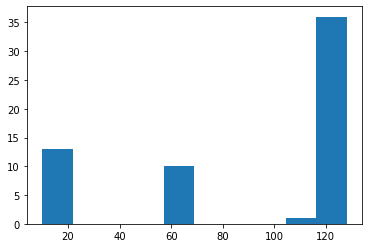

In [16]:
plt.hist(vc_asin)

In [17]:
np.min(vc_asin),np.max(vc_asin)

(10, 128)

In [18]:
vc_asin[vc_asin>120].reset_index()

,collection,asin,0
0,OLB FGM,B01NANZ5WG,128
1,OLB FGM,B01NH0QVM4,128
2,OLB FGM,B01NBPG153,128
3,OLB FGM,B01NBPG0LU,128
4,OLB FGM,B01NH0XWNU,128
5,OLB FGM,B01NH11UG3,128
6,OLB FGM,B01NANZ3HQ,128
7,OLB FGM,B01N1X5K70,128
8,OLB FGM,B01N0VNL1N,128
9,OLB FGM,B072M8JWGR,128


In [19]:
asin_gt_120 = vc_asin[vc_asin>120].reset_index().asin.unique()
asin_gt_120

array(['B01NANZ5WG', 'B01NH0QVM4', 'B01NBPG153', 'B01NBPG0LU',
       'B01NH0XWNU', 'B01NH11UG3', 'B01NANZ3HQ', 'B01N1X5K70',
       'B01N0VNL1N', 'B072M8JWGR', 'B01MU5FK81', 'B01MT3VRHV',
       'B01MT3VRFA', 'B01MS26EZ3', 'B072M8KWW1', 'B01NBPG1QV',
       'B00Q7EPSHI', 'B00Q7EVAXO', 'B072M8JWGQ', 'B071FVF3T7',
       'B01N7R9IHA', 'B01N4N3QJ1', 'B01MT85NGJ', 'B01MR51N1S',
       'B00Q7FWQKO', 'B00Q7EV7ZA', 'B00Q7EPV8O', 'B00Q7EV598',
       'B00Q7EV29G', 'B00Q7EUZLC', 'B00Q7EPY04', 'B00Q7EPFT4',
       'B00Q7EPILO', 'B00Q7EPLM0', 'B00Q7EPPDA', 'B074QTSBS2'],
      dtype=object)

In [20]:
len(asin_gt_120)

36

In [21]:
# Subsetting ASINs greater than 120 samples
df_gt = df_gt[df_gt.asin.isin(asin_gt_120)].copy()

## descriptive statistics

**`ord_rev`, `ord_qty`, `cnvrsn_rate` has negative values**

In [22]:
df_gt.describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,rvw_cnt,star12_cnt,star12_ratio
count,4.508000e+03,4508.000000,4507.000000,4459.000000,4508.000000,4455.000000,4471.000000,3357.000000,3357.000000,3357.000000
mean,9.078366e+04,357.985359,122.305747,260.599528,11230.910382,0.035287,0.077324,5.257671,1.349419,0.275347
std,2.583493e+05,908.667823,106.303513,106.249709,20653.707009,0.323579,0.214254,7.602618,2.222644,0.322849
min,-6.096816e+04,-251.000000,1.000000,40.868462,0.000000,-1.000000,0.000000,1.000000,0.000000,0.000000
25%,1.289655e+04,50.000000,46.000000,182.942012,2559.000000,0.015366,0.000000,1.000000,0.000000,0.000000
50%,3.282832e+04,139.000000,92.000000,238.793922,6080.500000,0.027356,0.006227,3.000000,1.000000,0.200000
75%,8.562102e+04,360.000000,164.000000,329.836897,13290.250000,0.042109,0.017236,6.000000,2.000000,0.500000
max,1.266026e+07,43825.000000,687.000000,744.240000,871072.000000,21.500000,1.000000,106.000000,30.000000,1.000000


In [23]:
NA_df_gt = dict()
cols = df_gt.columns
for col in cols:
    NA_df_gt[col] = sum(df_gt[col].isna())

In [24]:
NA_df_gt

{'asin': 0,
 'prdct_title': 0,
 'ord_rev': 0,
 'ord_qty': 0,
 'sale_rank': 1,
 'avg_price': 49,
 'gv': 0,
 'cnvrsn_rate': 53,
 'rep_oos': 37,
 'zinus_sku': 0,
 'collection': 0,
 'profile': 0,
 'size': 0,
 'rvw_cnt': 1151,
 'star12_cnt': 1151,
 'star12_ratio': 1151,
 'year_week': 0}

## drop negative values

In [25]:
rows_to_drop = (df_gt.ord_rev < 0) | (df_gt.ord_qty <0) | (df_gt.cnvrsn_rate <0)
sum(rows_to_drop)

16

In [26]:
neg_idx = rows_to_drop[rows_to_drop].index

In [27]:
df_gt.loc[neg_idx]

,asin,prdct_title,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,zinus_sku,collection,profile,size,rvw_cnt,star12_cnt,star12_ratio,year_week
48200,B074QTSBS2,Zinus 6 Inch Green Tea Memory Foam Mattress / ...,-308.74,-4,270,77.185000,0,NaN,0.000000,OLB-GTFM-6N,OLB GTFM,6 Inch,Narrow Twin,<NA>,<NA>,NaN,2020-09-20
68543,B00Q7EVAXO,Zinus 10 Inch Green Tea Memory Foam Mattress /...,-199.64,-1,119,199.640000,0,NaN,1.000000,OLB-GTFM-10F,OLB GTFM,10 Inch,Full,4,0,0.000000,2021-01-03
84997,B071FVF3T7,Zinus 6 Inch Green Tea Memory Foam Mattress / ...,-149.00,-1,116,149.000000,1,-1.000000,0.000000,OLB-GTFM-6SQ,OLB GTFM,6 Inch,Short Queen,<NA>,<NA>,NaN,2021-03-21
96627,B01MR51N1S,Zinus 6 Inch Green Tea Memory Foam Mattress / ...,-911.71,-15,29,60.780667,6453,-0.002325,1.000000,OLB-GTFM-6T,OLB GTFM,6 Inch,Twin,7,2,0.285714,2021-05-23
98017,B072M8KWW1,Zinus 8 Inch Gel-Infused Green Tea Memory Foam...,-1649.31,-5,249,329.860000,27,-0.185200,1.000000,OLB-FGM-0800SQ,OLB FGM,8 Inch,Short Queen,<NA>,<NA>,NaN,2021-05-30
101934,B072M8KWW1,Zinus 8 Inch Gel-Infused Green Tea Memory Foam...,-60968.16,-251,233,242.901036,16403,-0.015302,1.000000,OLB-FGM-0800SQ,OLB FGM,8 Inch,Short Queen,<NA>,<NA>,NaN,2021-06-20
110448,B01NH0QVM4,Zinus 10 Inch Gel-Infused Green Tea Memory Foa...,-595.80,-2,193,297.900000,11,-0.181818,0.000000,OLB-FGM-1000Q,OLB FGM,10 Inch,Queen,4,0,0.000000,2021-08-08
112539,B072M8JWGQ,Zinus 8 Inch Green Tea Memory Foam Mattress / ...,-1221.48,-6,181,203.580000,0,NaN,1.000000,OLB-GTFM-8SQ,OLB GTFM,8 Inch,Short Queen,<NA>,<NA>,NaN,2021-08-15
113193,B01NH0QVM4,Zinus 10 Inch Gel-Infused Green Tea Memory Foa...,-563.32,-2,151,281.660000,79,-0.025316,0.000000,OLB-FGM-1000Q,OLB FGM,10 Inch,Queen,6,1,0.166667,2021-08-22
113889,B072M8JWGQ,Zinus 8 Inch Green Tea Memory Foam Mattress / ...,-205.87,-1,38,205.870000,0,NaN,1.000000,OLB-GTFM-8SQ,OLB GTFM,8 Inch,Short Queen,<NA>,<NA>,NaN,2021-08-22


In [28]:
df_gt.drop(index=neg_idx,axis=0, inplace=True)

In [29]:
df_gt.describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,rvw_cnt,star12_cnt,star12_ratio
count,4.492000e+03,4492.000000,4491.000000,4443.000000,4492.000000,4443.000000,4455.000000,3348.000000,3348.000000,3348.000000
mean,9.112560e+04,359.345058,122.120463,260.793403,11263.648931,0.036096,0.075833,5.261649,1.350956,0.275355
std,2.587440e+05,909.991844,106.270259,106.156306,20681.545510,0.323074,0.211127,7.611511,2.224925,0.322616
min,0.000000e+00,0.000000,1.000000,65.672714,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.299960e+04,51.000000,46.000000,183.023088,2587.500000,0.015417,0.000000,1.000000,0.000000,0.000000
50%,3.303886e+04,140.000000,92.000000,238.845185,6109.500000,0.027423,0.006227,3.000000,1.000000,0.200000
75%,8.601431e+04,360.000000,164.000000,329.990000,13320.250000,0.042158,0.017178,6.000000,2.000000,0.500000
max,1.266026e+07,43825.000000,687.000000,744.240000,871072.000000,21.500000,1.000000,106.000000,30.000000,1.000000


## Aggregate to product group

In [30]:
# To ignore Full, Queen, King, Twin, Narrow Twin, Short Queen
df_gt['prd_agg'] = [prdct.split(sep=",")[0] for prdct in df_gt.prdct_title]

In [31]:
df_gt_agg = df_gt.groupby(['prd_agg','year_week']).aggregate({
    'ord_rev':'sum',
    'ord_qty':'sum',
    'sale_rank':['mean','max','min'],
    'avg_price':'mean',
    'gv': 'sum',
    'cnvrsn_rate': 'mean',
    'rep_oos':'mean',
    'rvw_cnt':'sum',
    'star12_cnt':'sum',
    'star12_ratio':'mean'
})
df_gt_agg.head()

ord_rev  \
                                                                     sum   
prd_agg                                            year_week               
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16  150461.97   
                                                   2022-01-23  118485.54   
                                                   2022-01-30  117162.77   
                                                   2022-02-06  118736.09   
                                                   2022-02-13  104028.35   

                                                              ord_qty  \
                                                                  sum   
prd_agg                                            year_week            
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16     425   
                                                   2022-01-23     332   
                                                   2022-01-30     328   
                                                   2022-02-06     340   
                                                   2022-02-13     295   

                                                               sale_rank       \
                                                                    mean  max   
prd_agg                                            year_week                    
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16  77.666667  108   
                                                   2022-01-23  86.333333  140   
                                                   2022-01-30       91.0  140   
                                                   2022-02-06       85.0  129   
                                                   2022-02-13  95.666667  136   

                                                                    avg_price  \
                                                              min        mean   
prd_agg                                            year_week                    
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16  31  384.982809   
                                                   2022-01-23  35  382.641517   
                                                   2022-01-30  31  379.512349   
                                                   2022-02-06  32  374.394200   
                                                   2022-02-13  55  373.556977   

                                                                 gv  \
                                                                sum   
prd_agg                                            year_week          
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16  9217   
                                                   2022-01-23  7157   
                                                   2022-01-30  6362   
                                                   2022-02-06  6883   
                                                   2022-02-13  6610   

                                                              cnvrsn_rate  \
                                                                     mean   
prd_agg                                            year_week                
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16    0.039791   
                                                   2022-01-23    0.041484   
                                                   2022-01-30    0.048602   
                                                   2022-02-06    0.042354   
                                                   2022-02-13    0.039667   

                                                                rep_oos  \
                                                                   mean   
prd_agg                                            year_week              
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16  0.002845   
                                                   2022-01-23  0.005987   
            

In [71]:
df_gt.prd_agg.unique().tolist()

['Zinus 10 Inch Green Tea Memory Foam Mattress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving',
 'Zinus 10 Inch Gel-Infused Green Tea Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
 'Zinus 12 Inch Green Tea Memory Foam Mattress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving',
 'Zinus 12 Inch Gel-Infused Green Tea Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
 'Zinus 6 Inch Green Tea Memory Foam Mattress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving',
 'Zinus 6 Inch Gel-Infused Green Tea Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
 'Zinus 8 Inch Green Tea Memory Foam Mattress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving',
 'Zinus 8 Inch Gel-Infused Green Tea Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
 'ZINUS 

In [70]:
[x[6:13] +' '+ x[40:] for x in df_gt.prd_agg.unique().tolist()]

['10 Inch ress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving',
 '10 Inch ry Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
 '12 Inch ress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving',
 '12 Inch ry Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
 '6 Inch  ess / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving',
 '6 Inch  y Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
 '8 Inch  ess / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving',
 '8 Inch  y Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
 '10 Inch ry Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
 '12 Inch ry Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
 '6 Inch  y Foam Mattress / Cooling Gel Foam / P

In [32]:
df_gt_agg.loc[(df_gt.prd_agg.unique()[1],slice(None))]

ord_rev ord_qty   sale_rank            avg_price     gv  \
                  sum     sum        mean  max min        mean    sum   
year_week                                                               
2020-01-05  193913.15     978        47.0   61  19  222.090354  23156   
2020-01-12  222877.88    1166        47.0   61  29  217.836325  27059   
2020-01-19  124587.60     606   57.333333   76  42  224.373794  19146   
2020-01-26   67570.91     339  112.666667  233  47  223.442363  13164   
2020-02-02   97748.98     513       109.0  233  47  217.607500  12409   
...               ...     ...         ...  ...  ..         ...    ...   
2021-12-12  186808.56     551  113.666667  180  52  407.436128   9896   
2021-12-19  133176.27     390  110.333333  180  48  398.231038   9210   
2021-12-26  187725.71     544   92.333333  122  37  388.548639  11149   
2022-01-02  176848.40     513   80.333333  118  30  390.242498  10695   
2022-01-09  174803.02     499   79.666667  114  32  387.637823  10559   

           cnvrsn_rate   rep_oos rvw_cnt star12_cnt star12_ratio  
                  mean      mean     sum        sum         mean  
year_week                                                         
2020-01-05    0.037397  0.001595      21          2     0.051282  
2020-01-12    0.038474  0.002100      22          0     0.000000  
2020-01-19    0.029259  0.243528      18          1     0.047619  
2020-01-26    0.020116  0.486378      19          1     0.033333  
2020-02-02    0.032129  0.335832      19          1     0.041667  
...                ...       ...     ...        ...          ...  
2021-12-12    0.037317  0.004883       4          1     0.250000  
2021-12-19    0.032189  0.005092       6          2     0.600000  
2021-12-26    0.039406  0.004741       3          1     0.500000  
2022-01-02    0.035974  0.004913       9          1     0.055556  
2022-01-09    0.037354  0.006088       5          2     0.400000  

[106 rows x 12 columns]

In [33]:
df_gt_agg.columns

MultiIndex([(     'ord_rev',  'sum'),
            (     'ord_qty',  'sum'),
            (   'sale_rank', 'mean'),
            (   'sale_rank',  'max'),
            (   'sale_rank',  'min'),
            (   'avg_price', 'mean'),
            (          'gv',  'sum'),
            ( 'cnvrsn_rate', 'mean'),
            (     'rep_oos', 'mean'),
            (     'rvw_cnt',  'sum'),
            (  'star12_cnt',  'sum'),
            ('star12_ratio', 'mean')],
           )

In [34]:
agg_cols=list()
for tp in list(df_gt_agg.columns):
    tplist = list(tp)
    agg_cols.extend([tplist[0]+'_'+tplist[1]])

In [35]:
agg_cols

['ord_rev_sum',
 'ord_qty_sum',
 'sale_rank_mean',
 'sale_rank_max',
 'sale_rank_min',
 'avg_price_mean',
 'gv_sum',
 'cnvrsn_rate_mean',
 'rep_oos_mean',
 'rvw_cnt_sum',
 'star12_cnt_sum',
 'star12_ratio_mean']

In [36]:
df_gt_agg.columns = agg_cols

In [37]:
df_gt_agg

ord_rev_sum  \
prd_agg                                            year_week                 
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16    150461.97   
                                                   2022-01-23    118485.54   
                                                   2022-01-30    117162.77   
                                                   2022-02-06    118736.09   
                                                   2022-02-13    104028.35   
...                                                                    ...   
Zinus 8 Inch Green Tea Memory Foam Mattress / C... 2022-05-15    121516.40   
                                                   2022-05-22    103738.22   
                                                   2022-05-29    149618.99   
                                                   2022-06-05    192588.83   
                                                   2022-06-12    228365.18   

                                                               ord_qty_sum  \
prd_agg                                            year_week                 
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16          425   
                                                   2022-01-23          332   
                                                   2022-01-30          328   
                                                   2022-02-06          340   
                                                   2022-02-13          295   
...                                                                    ...   
Zinus 8 Inch Green Tea Memory Foam Mattress / C... 2022-05-15          409   
                                                   2022-05-22          390   
                                                   2022-05-29          588   
                                                   2022-06-05          837   
                                                   2022-06-12          996   

                                                               sale_rank_mean  \
prd_agg                                            year_week                    
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16       77.666667   
                                                   2022-01-23       86.333333   
                                                   2022-01-30            91.0   
                                                   2022-02-06            85.0   
                                                   2022-02-13       95.666667   
...                                                                       ...   
Zinus 8 Inch Green Tea Memory Foam Mattress / C... 2022-05-15          168.75   
                                                   2022-05-22           237.2   
                                                   2022-05-29           196.4   
                                                   2022-06-05           119.0   
                                                   2022-06-12           120.4   

                                                               sale_rank_max  \
prd_agg                                            year_week                   
ZINUS 10 Inch Green Tea Cooling Gel Memory Foam... 2022-01-16            108   
                                                   2022-01-23            140   
                                                   2022-01-30            140   
                                                   2022-02-06            129   
                                                   2022-02-13            136   
...                                                                      ...   
Zinus 8 Inch Green Tea Memory Foam Mattress / C... 2022-05-15            387   
                                                   2022-05-22            377   
                                                   2022-05-29            377   
                                                   2022-06-05            169   
                   

## Replacing NA

* `avg_price` : ffill
* `sale_rank` : ffill
* `cnvrsn_rate` : ffill

* `gv` : 0
* `rep_oos` : 0
* `rvw_cnt` : 0
* `star12_cnt` : 0
* `star12_ratio` : 0

### date range and filling

In [38]:
dt_rg = pd.date_range(start='2020-01-05',end='2022-06-12',freq='W')
dt_rg.name='year_week'

In [39]:
df_gt_agg.columns

Index(['ord_rev_sum', 'ord_qty_sum', 'sale_rank_mean', 'sale_rank_max',
       'sale_rank_min', 'avg_price_mean', 'gv_sum', 'cnvrsn_rate_mean',
       'rep_oos_mean', 'rvw_cnt_sum', 'star12_cnt_sum', 'star12_ratio_mean'],
      dtype='object')

In [40]:
df_gt_agg.reset_index('prd_agg',inplace=True)

In [41]:
prd_agg = df_gt_agg.prd_agg.unique().tolist()

In [42]:
# columns to be lagged and appended
#metrics = ['sale_rank_mean', 'sale_rank_max', 'sale_rank_min', \
#           'avg_price_mean', 'gv_sum', 'cnvrsn_rate_mean',\
#           'rep_oos_mean', 'rvw_cnt_sum', \
#           'star12_cnt_sum', 'star12_ratio_mean']

df_set = pd.DataFrame(columns=df_gt_agg.columns)

for prdagg in prd_agg:
    tmp_df = pd.DataFrame(index=dt_rg)
    tmp_df = tmp_df.join(df_gt_agg[df_gt_agg.prd_agg==prdagg])
    tmp_df.sort_values(by='year_week',inplace=True)
    
    # For meaningfull ffill(), need to fill '0' first row.
    tmp_df[:1] = tmp_df[:1].fillna(0)
    
    tmp_df = tmp_df.resample('W-Sun').mean()
    tmp_df['prd_agg']=prdagg
    
    tmp_df[['ord_rev_sum', 'ord_qty_sum']] = \
            tmp_df[['ord_rev_sum', 'ord_qty_sum']].ffill()
        
    tmp_df[['sale_rank_mean', 'sale_rank_max', 'sale_rank_min','avg_price_mean', 'cnvrsn_rate_mean']] = \
            tmp_df[['sale_rank_mean', 'sale_rank_max', 'sale_rank_min','avg_price_mean', 'cnvrsn_rate_mean']].ffill()
    tmp_df[['gv_sum','rep_oos_mean', 'rvw_cnt_sum','star12_cnt_sum', 'star12_ratio_mean']] = \
            tmp_df[['gv_sum','rep_oos_mean', 'rvw_cnt_sum','star12_cnt_sum', 'star12_ratio_mean']].fillna(0)
    
    # Ill conditioned quickly
    #for metric in metrics:
    #    for k in range(4):
    #        metric_lag = tmp_df[metric].shift(k+1)
    #        tmp_df[metric+'_lag'+str(k+1)] = metric_lag
    #tmp_df.dropna(inplace=True)
    
    tmp_df.reset_index(inplace=True)
    df_set = df_set.append(tmp_df)

In [43]:
df_gt_agg.shape

(1000, 13)

In [44]:
df_set.shape

(1536, 14)

In [45]:
df_set.head(5)

,prd_agg,ord_rev_sum,ord_qty_sum,sale_rank_mean,sale_rank_max,sale_rank_min,avg_price_mean,gv_sum,cnvrsn_rate_mean,rep_oos_mean,rvw_cnt_sum,star12_cnt_sum,star12_ratio_mean,year_week
0,ZINUS 10 Inch Green Tea Cooling Gel Memory Foa...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-05
1,ZINUS 10 Inch Green Tea Cooling Gel Memory Foa...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-12
2,ZINUS 10 Inch Green Tea Cooling Gel Memory Foa...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-19
3,ZINUS 10 Inch Green Tea Cooling Gel Memory Foa...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-01-26
4,ZINUS 10 Inch Green Tea Cooling Gel Memory Foa...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020-02-02


## Inch inforamtion

In [46]:
df_gt.collection.unique()

array(['OLB GTFM', 'OLB FGM'], dtype=object)

In [47]:
coll_inch = df_gt[['collection','profile']].pivot_table(index='collection',columns='profile',aggfunc=np.unique)
coll_inch

profile,10 Inch,12 inch,6 Inch,8 Inch
collection,,,,
OLB FGM,"[10 Inch, OLB FGM]","[12 inch, OLB FGM]","[6 Inch, OLB FGM]","[8 Inch, OLB FGM]"
OLB GTFM,"[10 Inch, OLB GTFM]","[12 inch, OLB GTFM]","[6 Inch, OLB GTFM]","[8 Inch, OLB GTFM]"


# Modeling

## Linear model

In [48]:
df_set.columns

Index(['prd_agg', 'ord_rev_sum', 'ord_qty_sum', 'sale_rank_mean',
       'sale_rank_max', 'sale_rank_min', 'avg_price_mean', 'gv_sum',
       'cnvrsn_rate_mean', 'rep_oos_mean', 'rvw_cnt_sum', 'star12_cnt_sum',
       'star12_ratio_mean', 'year_week'],
      dtype='object')

In [49]:
p = list(set(df_set.columns)-set(['ord_rev_sum','ord_qty_sum','prd_agg','year_week']))
p.sort()

In [50]:
predictors = ['Intercept'] + p
predictors = predictors
predictors

['Intercept',
 'avg_price_mean',
 'cnvrsn_rate_mean',
 'gv_sum',
 'rep_oos_mean',
 'rvw_cnt_sum',
 'sale_rank_max',
 'sale_rank_mean',
 'sale_rank_min',
 'star12_cnt_sum',
 'star12_ratio_mean']

In [51]:
expr='ord_rev_sum ~ '
for pred in predictors[1:]:
    expr = expr+pred+' + '
expr = expr[:-3]

expr

'ord_rev_sum ~ avg_price_mean + cnvrsn_rate_mean + gv_sum + rep_oos_mean + rvw_cnt_sum + sale_rank_max + sale_rank_mean + sale_rank_min + star12_cnt_sum + star12_ratio_mean'

**This does not give results using full predictors, due to ill-conditioned inverse**

In [52]:
typeset_dict = dict()
df_set_cols = [col for col in df_set.columns[1:] if col != 'year_week']
for col in df_set_cols:
    typeset_dict[col] = 'float64'

In [53]:
typeset_dict

{'ord_rev_sum': 'float64',
 'ord_qty_sum': 'float64',
 'sale_rank_mean': 'float64',
 'sale_rank_max': 'float64',
 'sale_rank_min': 'float64',
 'avg_price_mean': 'float64',
 'gv_sum': 'float64',
 'cnvrsn_rate_mean': 'float64',
 'rep_oos_mean': 'float64',
 'rvw_cnt_sum': 'float64',
 'star12_cnt_sum': 'float64',
 'star12_ratio_mean': 'float64'}

In [54]:
df_set.columns

Index(['prd_agg', 'ord_rev_sum', 'ord_qty_sum', 'sale_rank_mean',
       'sale_rank_max', 'sale_rank_min', 'avg_price_mean', 'gv_sum',
       'cnvrsn_rate_mean', 'rep_oos_mean', 'rvw_cnt_sum', 'star12_cnt_sum',
       'star12_ratio_mean', 'year_week'],
      dtype='object')

If we used lagged features, most of the product group (level of analysis) **fail** to get linear model due to multi-colinearity. So decided not to use those, rather build model **using original features**.

In [55]:
cols = predictors + ['p_'+x for x in predictors] + ['R2','model']
df_ols_all = pd.DataFrame(columns=cols,index=prd_agg)

for prdagg in prd_agg:
    tmp_df_set = df_set[df_set.prd_agg==prdagg].copy()
    

    tmp_df_set = tmp_df_set.astype(typeset_dict)
    
    model = sm.OLS.from_formula(expr, data=tmp_df_set)
    result = model.fit()
    tmp_ols = result.summary().tables[1].data

    coeffs = list()
    p_coeffs = list()
    for k in range(len(predictors)): # Without Intercept
        coeffs.append(float(tmp_ols[k+1][1])) # Coefficients
        p_coeffs.append(float(tmp_ols[k+1][4])) # P > |t|
    coeffs.extend(p_coeffs)
    
    r2 = [float(result.summary().tables[0].data[0][-1])] # R-squrared
    coeffs.extend(r2)
    coeffs.extend([model])
    df_ols_all.loc[prdagg] = coeffs
    
    print(f"model rank : %d" %model.rank)
    del tmp_df_set, tmp_ols, result, coeffs, p_coeffs, r2

model rank : 11
model rank : 10
model rank : 11
model rank : 11
model rank : 11
model rank : 11
model rank : 10
model rank : 11
model rank : 11
model rank : 11
model rank : 11
model rank : 11


## Performance evaluation

### R2 

In [56]:
df_ols_all.index

Index(['ZINUS 10 Inch Green Tea Cooling Gel Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
       'ZINUS 12 Inch Green Tea Cooling Gel Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
       'ZINUS 6 Inch Green Tea Cooling Gel Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
       'ZINUS 8 Inch Green Tea Cooling Gel Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
       'Zinus 10 Inch Gel-Infused Green Tea Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
       'Zinus 10 Inch Green Tea Memory Foam Mattress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving',
       'Zinus 12 Inch Gel-Infused Green Tea Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box',
       'Zin

In [57]:
df_ols_all.R2.tolist()

[0.944,
 0.976,
 0.995,
 0.99,
 0.957,
 0.842,
 0.961,
 0.934,
 0.813,
 0.612,
 0.867,
 0.782]

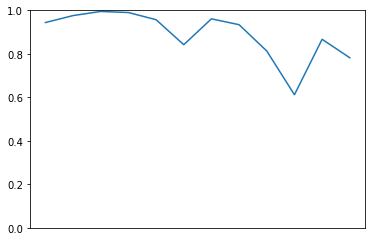

In [59]:
df_ols_all.R2.plot(ylim=[0,1],xticks=[])
plt.show()

In [59]:
df_ols_all.index[-3]

'Zinus 6 Inch Green Tea Memory Foam Mattress / CertiPUR-US Certified / Bed-in-a-Box / Pressure Relieving'

### number of predictors having p value < 0.05

In [60]:
pVal = df_ols_all[['p_'+x for x in predictors]]<0.05

In [61]:
pVal['n_count'] = [sum(row) for _,row in pVal.iterrows()]

In [62]:
pVal.columns

Index(['p_Intercept', 'p_avg_price_mean', 'p_cnvrsn_rate_mean', 'p_gv_sum',
       'p_rep_oos_mean', 'p_rvw_cnt_sum', 'p_sale_rank_max',
       'p_sale_rank_mean', 'p_sale_rank_min', 'p_star12_cnt_sum',
       'p_star12_ratio_mean', 'n_count'],
      dtype='object')

In [63]:
pVal.n_count.describe().round()

count    12.0
mean      6.0
std       2.0
min       3.0
25%       5.0
50%       6.0
75%       6.0
max       9.0
Name: n_count, dtype: float64

In [64]:
predictors

['Intercept',
 'avg_price_mean',
 'cnvrsn_rate_mean',
 'gv_sum',
 'rep_oos_mean',
 'rvw_cnt_sum',
 'sale_rank_max',
 'sale_rank_mean',
 'sale_rank_min',
 'star12_cnt_sum',
 'star12_ratio_mean']

In [65]:
pVal.sum()

p_Intercept             7
p_avg_price_mean        8
p_cnvrsn_rate_mean     10
p_gv_sum               12
p_rep_oos_mean          5
p_rvw_cnt_sum           7
p_sale_rank_max         2
p_sale_rank_mean        2
p_sale_rank_min         4
p_star12_cnt_sum        5
p_star12_ratio_mean     9
n_count                71
dtype: int64

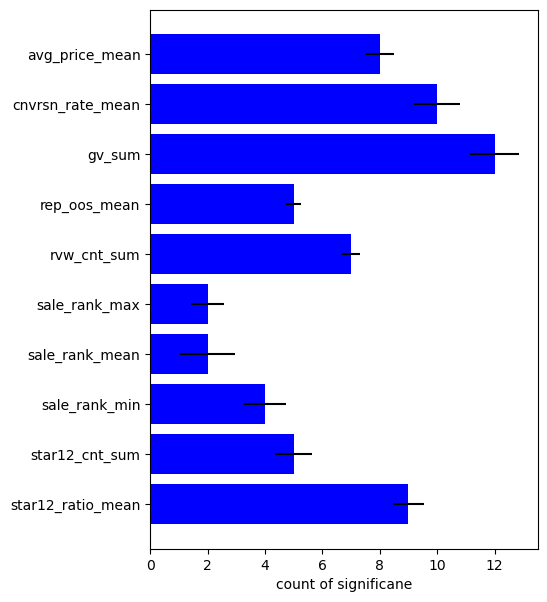

In [66]:
plt.rcdefaults()
fig, ax = plt.subplots(figsize=(5,7))

# Example data
predtrs = predictors[1:]
y_pos = np.arange(len(predtrs))
performance = pVal.sum()[1:-1]
error = np.random.rand(len(predtrs))

ax.barh(y_pos, performance, color='b', xerr=error, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(predtrs,fontsize=10)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('count of significane',fontsize=10)
plt.yticks(rotation=0)
plt.show()

### Scatter plot of maximum number of predictors

In [67]:
pVal[pVal.n_count>8]

,p_Intercept,p_avg_price_mean,p_cnvrsn_rate_mean,p_gv_sum,p_rep_oos_mean,p_rvw_cnt_sum,p_sale_rank_max,p_sale_rank_mean,p_sale_rank_min,p_star12_cnt_sum,p_star12_ratio_mean,n_count
ZINUS 8 Inch Green Tea Cooling Gel Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box,False,False,True,True,True,True,True,True,True,True,True,9


In [68]:
df_ols_all.loc[pVal[pVal.n_count>8].index]

,Intercept,avg_price_mean,cnvrsn_rate_mean,gv_sum,rep_oos_mean,rvw_cnt_sum,sale_rank_max,sale_rank_mean,sale_rank_min,star12_cnt_sum,...,p_gv_sum,p_rep_oos_mean,p_rvw_cnt_sum,p_sale_rank_max,p_sale_rank_mean,p_sale_rank_min,p_star12_cnt_sum,p_star12_ratio_mean,R2,model
ZINUS 8 Inch Green Tea Cooling Gel Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box,-10.2047,-61.4239,1718000.0,8.3874,-421900.0,-3857.7725,172.5435,-639.9371,735.7303,4935.6554,...,0.0,0.0,0.0,0.0,0.0,0.0,0.047,0.0,0.99,<statsmodels.regression.linear_model.OLS objec...


In [69]:
result = df_ols_all.loc[pVal[pVal.n_count>8].index].model.values[0].fit()

In [70]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            ord_rev_sum   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     1188.
Date:                Tue, 26 Jul 2022   Prob (F-statistic):          1.30e-112
Time:                        12:02:41   Log-Likelihood:                -1288.9
No. Observations:                 128   AIC:                             2600.
Df Residuals:                     117   BIC:                             2631.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           -10.2047    580.566     -0.018      0.986   -1159.985    1139.576
avg_price_mean      -61.4239     42.370     -1.450      0.150    -145.336      22.488
cnvrsn_rate_mean   1.718e+06   1.56e+05     10.984      0.000    1.41e+06    2.03e+06
gv_sum                8.3874      0.218     38.486      0.000       7.956       8.819
rep_oos_mean      -4.219e+05   9.07e+04     -4.653      0.000   -6.01e+05   -2.42e+05
rvw_cnt_sum       -3857.7725    893.322     -4.318      0.000   -5626.950   -2088.596
sale_rank_max       172.5435     41.756      4.132      0.000      89.848     255.239
sale_rank_mean     -639.9371    142.806     -4.481      0.000    -922.757    -357.118
sale_rank_min       735.7303    127.691      5.762      0.000     482.845     988.615
star12_cnt_sum     4935.6554   2455.645      2.010      0.047      72.378    9798.932
star12_ratio_mean -2.787e+04   7286.545     -3.825      0.000   -4.23e+04   -1.34e+04
==============================================================================
Omnibus:                       97.520   Durbin-Watson:                   2.257
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2273.325
Skew:                           2.128   Prob(JB):                         0.00
Kurtosis:                      23.202   Cond. No.                     1.72e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.72e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1


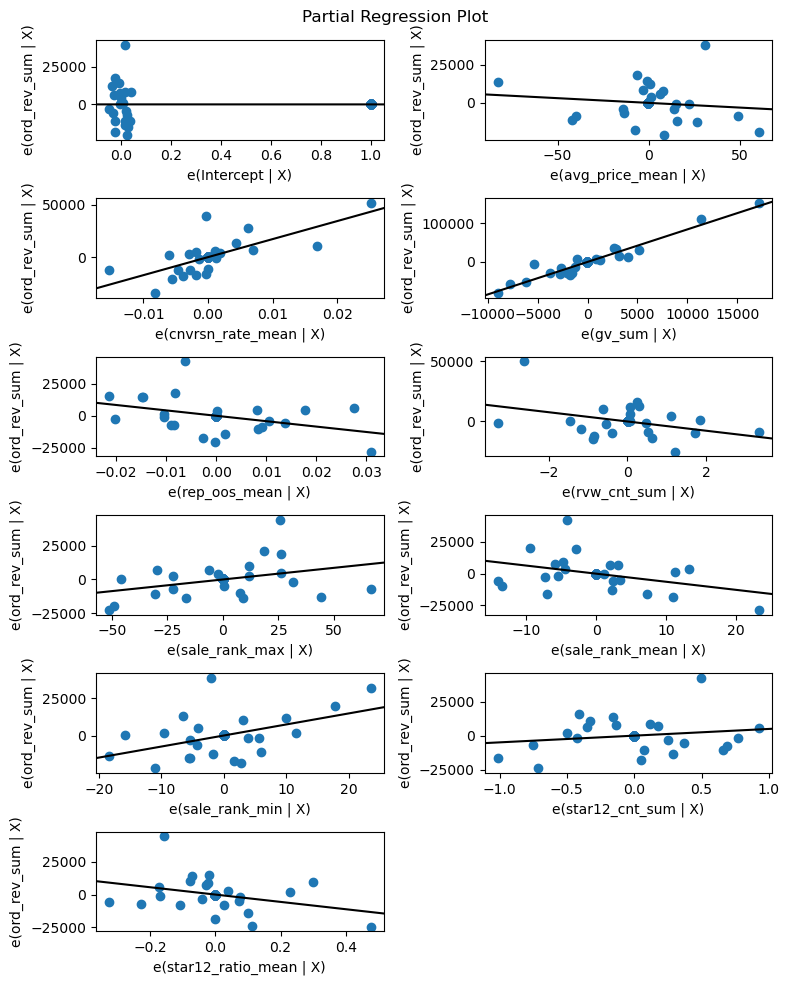

In [71]:
fig = plt.figure(figsize=(8, 10))
plot_partregress_grid(result, fig=fig)
plt.show()

# What-if Analysis

To salient experiments, need to update models so that each model has significant features per p-values.
But for the sake of :
- Overall working scenarios
- For the brevity

## Interaction terms

### Using linear regression

In [75]:
prdagg = prd_agg[8]
prdagg

'Zinus 6 Inch Gel-Infused Green Tea Memory Foam Mattress / Cooling Gel Foam / Pressure Relieving / CertiPUR-US Certified / Bed-in-a-Box'

In [76]:
p = list(set(df_set.columns)-set(['ord_rev_sum','ord_qty_sum','prd_agg','year_week']))
p.sort()

predictors = ['Intercept'] + p
predictors = predictors

expr='ord_rev_sum ~ '
indep_term = ''
for pred in predictors[1:]:
    indep_term = indep_term+pred+' + '
indep_term = indep_term[:-3]
expr = expr + indep_term
expr

'ord_rev_sum ~ avg_price_mean + cnvrsn_rate_mean + gv_sum + rep_oos_mean + rvw_cnt_sum + sale_rank_max + sale_rank_mean + sale_rank_min + star12_cnt_sum + star12_ratio_mean'

In [77]:
typeset_dict = dict()
df_set_cols = [col for col in df_set.columns[1:] if col != 'year_week']
for col in df_set_cols:
    typeset_dict[col] = 'float64'

In [78]:
tmp_df_set = df_set[df_set.prd_agg==prdagg].copy()   
tmp_df_set = tmp_df_set.astype(typeset_dict)

model = sm.OLS.from_formula(expr, data=tmp_df_set)
result = model.fit()
tmp_ols = result.summary().tables[1].data

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            ord_rev_sum   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     50.80
Date:                Mon, 08 Aug 2022   Prob (F-statistic):           6.85e-38
Time:                        12:03:14   Log-Likelihood:                -1550.7
No. Observations:                 128   AIC:                             3123.
Df Residuals:                     117   BIC:                             3155.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -2.039e+04   4.52e+04     -0.451      0.652    -1.1e+05    6.91e+04
avg_price_mean      168.2398    210.354      0.800      0.425    -248.355     584.834
cnvrsn_rate_mean   1.727e+06    2.1e+05      8.244      0.000    1.31e+06    2.14e+06
gv_sum                4.3254      0.457      9.471      0.000       3.421       5.230
rep_oos_mean       3.805e+04    4.9e+04      0.777      0.439    -5.9e+04    1.35e+05
rvw_cnt_sum       -6256.0446   1682.397     -3.719      0.000   -9587.944   -2924.145
sale_rank_max       -26.5449    100.840     -0.263      0.793    -226.254     173.164
sale_rank_mean      -39.0469    231.967     -0.168      0.867    -498.446     420.352
sale_rank_min      -274.4756    194.962     -1.408      0.162    -660.588     111.637
star12_cnt_sum     3.306e+04   5878.079      5.624      0.000    2.14e+04    4.47e+04
star12_ratio_mean -8.224e+04   2.27e+04     -3.621      0.000   -1.27e+05   -3.73e+04
==============================================================================
Omnibus:                       18.208   Durbin-Watson:                   1.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               77.979
Skew:                           0.175   Prob(JB):                     1.17e-17
Kurtosis:                       6.808   Cond. No.                     1.11e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.11e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Model update (1)

In [79]:
p_coeffs = list()
for k in range(len(predictors)): # Without Intercept
        p_coeffs.append(float(tmp_ols[k+1][4])) # P > |t|

In [80]:
predictors

['Intercept',
 'avg_price_mean',
 'cnvrsn_rate_mean',
 'gv_sum',
 'rep_oos_mean',
 'rvw_cnt_sum',
 'sale_rank_max',
 'sale_rank_mean',
 'sale_rank_min',
 'star12_cnt_sum',
 'star12_ratio_mean']

In [81]:
mask = [p_coeff <0.05 for p_coeff in p_coeffs]
sig_preds = pd.Series(mask,index=predictors)

In [82]:
predictors1 = sig_preds.index[sig_preds.values].tolist()
predictors1

['cnvrsn_rate_mean',
 'gv_sum',
 'rvw_cnt_sum',
 'star12_cnt_sum',
 'star12_ratio_mean']

In [83]:
expr='ord_rev_sum ~ '
indep_term = ''
for pred in predictors1:
    indep_term = indep_term+pred+' + '
indep_term = indep_term[:-3]

# We don't have intercept term above
expr = expr + indep_term + '-1'
expr

'ord_rev_sum ~ cnvrsn_rate_mean + gv_sum + rvw_cnt_sum + star12_cnt_sum + star12_ratio_mean-1'

In [84]:
model1 = sm.OLS.from_formula(expr, data=tmp_df_set)
result1 = model1.fit()
tmp_ols1 = result1.summary().tables[1].data

result1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            ord_rev_sum   R-squared (uncentered):                   0.855
Model:                            OLS   Adj. R-squared (uncentered):              0.850
Method:                 Least Squares   F-statistic:                              145.6
Date:                Mon, 08 Aug 2022   Prob (F-statistic):                    6.58e-50
Time:                        12:03:18   Log-Likelihood:                         -1566.9
No. Observations:                 128   AIC:                                      3144.
Df Residuals:                     123   BIC:                                      3158.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
cnvrsn_rate_mean   1.273e+06   1.54e+05      8.277      0.000    9.69e+05    1.58e+06
gv_sum                4.0425      0.421      9.591      0.000       3.208       4.877
rvw_cnt_sum       -9414.3409   1572.097     -5.988      0.000   -1.25e+04   -6302.471
star12_cnt_sum     4.813e+04   5639.345      8.535      0.000     3.7e+04    5.93e+04
star12_ratio_mean -1.261e+05   2.34e+04     -5.382      0.000   -1.72e+05   -7.97e+04
==============================================================================
Omnibus:                       18.301   Durbin-Watson:                   0.941
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               45.762
Skew:                           0.497   Prob(JB):                     1.16e-10
Kurtosis:                       5.756   Cond. No.                     7.39e+05
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 7.39e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Model update (2) : pairwise interactions

In [85]:
p_coeffs = list()
for k in range(len(predictors1)): # Without Intercept
        p_coeffs.append(float(tmp_ols1[k+1][4])) # P > |t|

In [86]:
mask = [p_coeff <0.05 for p_coeff in p_coeffs]
sig_preds = pd.Series(mask,index=predictors1)

In [87]:
predictors2 = sig_preds.index[sig_preds.values].tolist()
predictors2

['cnvrsn_rate_mean',
 'gv_sum',
 'rvw_cnt_sum',
 'star12_cnt_sum',
 'star12_ratio_mean']

In [88]:
expr='ord_rev_sum ~ '
indep_term = '('
for pred in predictors2:
    indep_term = indep_term+pred+' + '
indep_term = indep_term[:-3]

# We don't have intercept term above
expr = expr + indep_term +') **2 '+ '-1'
expr

'ord_rev_sum ~ (cnvrsn_rate_mean + gv_sum + rvw_cnt_sum + star12_cnt_sum + star12_ratio_mean) **2 -1'

In [89]:
model2 = sm.OLS.from_formula(expr, data=tmp_df_set)
result2 = model2.fit()
tmp_ols2 = result2.summary().tables[1].data

result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            ord_rev_sum   R-squared (uncentered):                   0.965
Model:                            OLS   Adj. R-squared (uncentered):              0.961
Method:                 Least Squares   F-statistic:                              209.4
Date:                Mon, 08 Aug 2022   Prob (F-statistic):                    5.57e-75
Time:                        12:03:21   Log-Likelihood:                         -1475.6
No. Observations:                 128   AIC:                                      2981.
Df Residuals:                     113   BIC:                                      3024.
Df Model:                          15                                                  
Covariance Type:            nonrobust                                                  
======================================================================================================
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cnvrsn_rate_mean                     7.14e+05   1.08e+05      6.604      0.000       5e+05    9.28e+05
gv_sum                                -0.2194      0.456     -0.482      0.631      -1.122       0.683
rvw_cnt_sum                         2406.2229   1756.525      1.370      0.173   -1073.771    5886.216
star12_cnt_sum                      5265.7094   9078.478      0.580      0.563   -1.27e+04    2.33e+04
star12_ratio_mean                  -1.325e+05   3.15e+04     -4.202      0.000   -1.95e+05      -7e+04
cnvrsn_rate_mean:gv_sum              134.1913     14.286      9.393      0.000     105.888     162.494
cnvrsn_rate_mean:rvw_cnt_sum       -6.559e+04   4.06e+04     -1.614      0.109   -1.46e+05    1.49e+04
cnvrsn_rate_mean:star12_cnt_sum    -3.905e+05   1.53e+05     -2.545      0.012   -6.95e+05   -8.65e+04
cnvrsn_rate_mean:star12_ratio_mean   5.34e+05   4.71e+05      1.135      0.259   -3.98e+05    1.47e+06
gv_sum:rvw_cnt_sum                    -0.0908      0.041     -2.187      0.031      -0.173      -0.009
gv_sum:star12_cnt_sum                  0.0731      0.270      0.271      0.787      -0.462       0.608
gv_sum:star12_ratio_mean               4.6662      1.895      2.462      0.015       0.911       8.421
rvw_cnt_sum:star12_cnt_sum          -822.8495    710.859     -1.158      0.249   -2231.190     585.491
rvw_cnt_sum:star12_ratio_mean        1.14e+04   7722.486      1.476      0.143   -3899.084    2.67e+04
star12_cnt_sum:star12_ratio_mean    3.674e+04   1.11e+04      3.305      0.001    1.47e+04    5.88e+04
==============================================================================
Omnibus:                       13.448   Durbin-Watson:                   1.274
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               23.309
Skew:                          -0.467   Prob(JB):                     8.68e-06
Kurtosis:                       4.871   Cond. No.                     5.42e+07
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 5.42e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Model update (3) : reduced pairwise interactions

In [90]:
[ [res[0],res[4]] for res in tmp_ols2[1:] if float(res[4]) < 0.05]

[['cnvrsn_rate_mean', ' 0.000'],
 ['star12_ratio_mean', ' 0.000'],
 ['cnvrsn_rate_mean:gv_sum', ' 0.000'],
 ['cnvrsn_rate_mean:star12_cnt_sum', ' 0.012'],
 ['gv_sum:rvw_cnt_sum', ' 0.031'],
 ['gv_sum:star12_ratio_mean', ' 0.015'],
 ['star12_cnt_sum:star12_ratio_mean', ' 0.001']]

In [91]:
predictors3 = [ res[0] for res in tmp_ols2[1:] if float(res[4]) < 0.05]
predictors3

['cnvrsn_rate_mean',
 'star12_ratio_mean',
 'cnvrsn_rate_mean:gv_sum',
 'cnvrsn_rate_mean:star12_cnt_sum',
 'gv_sum:rvw_cnt_sum',
 'gv_sum:star12_ratio_mean',
 'star12_cnt_sum:star12_ratio_mean']

In [92]:
expr='ord_rev_sum ~ '
indep_term = ''
for pred in predictors3:
    indep_term = indep_term+pred+' + '
indep_term = indep_term[:-3]

# We don't have intercept term above
expr = expr + indep_term + '-1'
expr

'ord_rev_sum ~ cnvrsn_rate_mean + star12_ratio_mean + cnvrsn_rate_mean:gv_sum + cnvrsn_rate_mean:star12_cnt_sum + gv_sum:rvw_cnt_sum + gv_sum:star12_ratio_mean + star12_cnt_sum:star12_ratio_mean-1'

In [93]:
model3 = sm.OLS.from_formula(expr, data=tmp_df_set)
result3 = model3.fit()
tmp_ols3 = result3.summary().tables[1].data

result3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            ord_rev_sum   R-squared (uncentered):                   0.962
Model:                            OLS   Adj. R-squared (uncentered):              0.960
Method:                 Least Squares   F-statistic:                              436.6
Date:                Mon, 08 Aug 2022   Prob (F-statistic):                    1.14e-82
Time:                        12:03:27   Log-Likelihood:                         -1481.5
No. Observations:                 128   AIC:                                      2977.
Df Residuals:                     121   BIC:                                      2997.
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
cnvrsn_rate_mean                  7.781e+05   9.05e+04      8.602      0.000    5.99e+05    9.57e+05
star12_ratio_mean                -8.813e+04   1.38e+04     -6.407      0.000   -1.15e+05   -6.09e+04
cnvrsn_rate_mean:gv_sum            110.9860      8.429     13.168      0.000      94.299     127.673
cnvrsn_rate_mean:star12_cnt_sum  -3.485e+05   7.88e+04     -4.424      0.000   -5.04e+05   -1.93e+05
gv_sum:rvw_cnt_sum                  -0.0630      0.017     -3.682      0.000      -0.097      -0.029
gv_sum:star12_ratio_mean             6.6363      0.965      6.875      0.000       4.725       8.547
star12_cnt_sum:star12_ratio_mean  3.979e+04   8784.450      4.529      0.000    2.24e+04    5.72e+04
==============================================================================
Omnibus:                       31.542   Durbin-Watson:                   1.308
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               80.480
Skew:                          -0.935   Prob(JB):                     3.34e-18
Kurtosis:                       6.405   Cond. No.                     9.90e+06
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 9.9e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Interaction plots

In [94]:
from statsmodels.graphics.factorplots import interaction_plot

In [95]:
tmp_df_set.cnvrsn_rate_mean.value_counts()

0.037352    23
0.035463     2
0.061149     1
0.060510     1
0.031179     1
            ..
0.010438     1
0.012910     1
0.007518     1
0.006767     1
0.015025     1
Name: cnvrsn_rate_mean, Length: 105, dtype: int64

In [96]:
tmp_df_set.gv_sum.value_counts()

0.0        22
32003.0     2
19119.0     1
14733.0     1
14672.0     1
           ..
29399.0     1
24810.0     1
21187.0     1
24393.0     1
22944.0     1
Name: gv_sum, Length: 106, dtype: int64

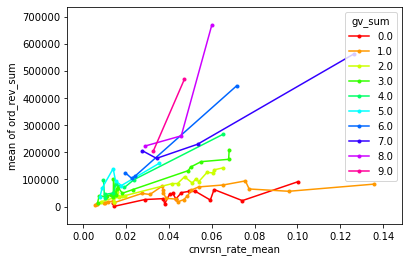

In [97]:
fig = interaction_plot(tmp_df_set.cnvrsn_rate_mean, (tmp_df_set.gv_sum/7000).round(0), result3.fittedvalues,
              xlabel='cnvrsn_rate_mean', ylabel='ord_rev_sum')

plt.show()

In [98]:
tmp_df_set.star12_cnt_sum.value_counts()

0.0    56
1.0    35
2.0    18
3.0    11
4.0     4
5.0     3
9.0     1
Name: star12_cnt_sum, dtype: int64

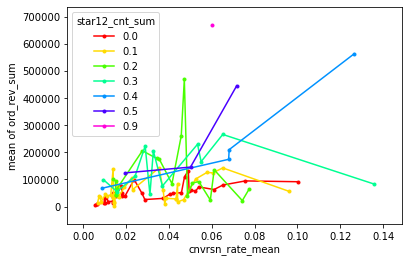

In [99]:
from statsmodels.graphics.factorplots import interaction_plot
fig = interaction_plot(tmp_df_set.cnvrsn_rate_mean, (tmp_df_set.star12_cnt_sum/10).round(1), result3.fittedvalues,
              xlabel='cnvrsn_rate_mean', ylabel='ord_rev_sum')

plt.show()

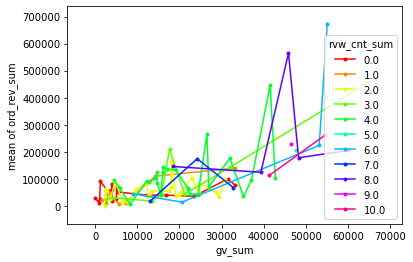

In [100]:
from statsmodels.graphics.factorplots import interaction_plot
fig = interaction_plot(tmp_df_set.gv_sum, (tmp_df_set.rvw_cnt_sum/2).round(0), result3.fittedvalues,
              xlabel='gv_sum', ylabel='ord_rev_sum')

plt.show()

In [101]:
tmp_df_set.star12_ratio_mean.value_counts()

0.000000    56
0.250000     8
0.500000     8
1.000000     6
0.333333     6
0.166667     5
0.111111     3
0.222222     3
0.125000     3
0.083333     3
0.138889     3
0.050000     2
0.261905     1
0.233333     1
0.416667     1
0.388889     1
0.071429     1
0.319444     1
0.238095     1
0.466667     1
0.771429     1
0.533333     1
0.666667     1
0.277778     1
0.285714     1
0.200000     1
0.321429     1
0.062500     1
0.187500     1
0.100000     1
0.241667     1
0.095238     1
0.260417     1
0.833333     1
Name: star12_ratio_mean, dtype: int64

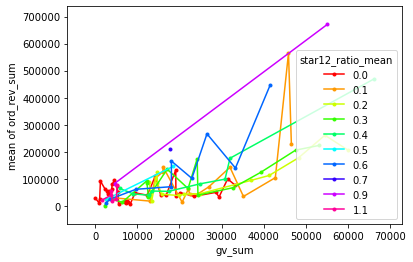

In [102]:
from statsmodels.graphics.factorplots import interaction_plot
fig = interaction_plot(tmp_df_set.gv_sum, (tmp_df_set.star12_ratio_mean/0.9).round(1), result3.fittedvalues,
              xlabel='gv_sum', ylabel='ord_rev_sum')

plt.show()

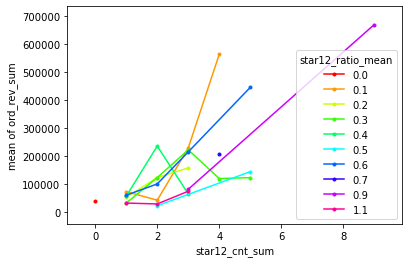

In [103]:
from statsmodels.graphics.factorplots import interaction_plot
fig = interaction_plot(tmp_df_set.star12_cnt_sum, (tmp_df_set.star12_ratio_mean/0.9).round(1), result3.fittedvalues,
              xlabel='star12_cnt_sum', ylabel='ord_rev_sum')

plt.show()

## Feasible scenarios

In [108]:
pVal.sum()[1:-1].sort_values(ascending=False)

p_gv_sum               12
p_cnvrsn_rate_mean     10
p_star12_ratio_mean     9
p_avg_price_mean        8
p_rvw_cnt_sum           7
p_rep_oos_mean          5
p_star12_cnt_sum        5
p_sale_rank_min         4
p_sale_rank_max         2
p_sale_rank_mean        2
dtype: int64

We compose scenarios using top $5$ features :
- gv
- cnvrsn_rate
- star12_ratio
- avg_price
- rvw_cnt

### Can we assume that `gv` and `avg_price` are independent?

In [109]:
df_set[df_set.prd_agg==prd_agg[0]].gv_sum.describe()

count      128.000000
mean      1391.757812
std       3460.756025
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      18622.000000
Name: gv_sum, dtype: float64

In [110]:
df_set[df_set.prd_agg==prd_agg[8]][['gv_sum','avg_price_mean']].describe()

,gv_sum,avg_price_mean
count,128.000000,128.000000
mean,15322.671875,174.379413
std,15412.766919,31.310936
min,0.000000,111.796776
25%,3096.750000,152.715658
50%,12478.500000,180.219904
75%,23068.750000,203.374736
max,66274.000000,214.733539


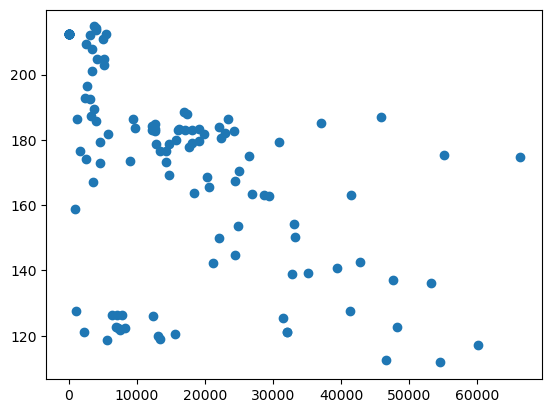

In [111]:
x = df_set[df_set.prd_agg==prd_agg[8]].gv_sum
y = df_set[df_set.prd_agg==prd_agg[8]].avg_price_mean
plt.scatter(x,y)

In [112]:
len(prd_agg)

12

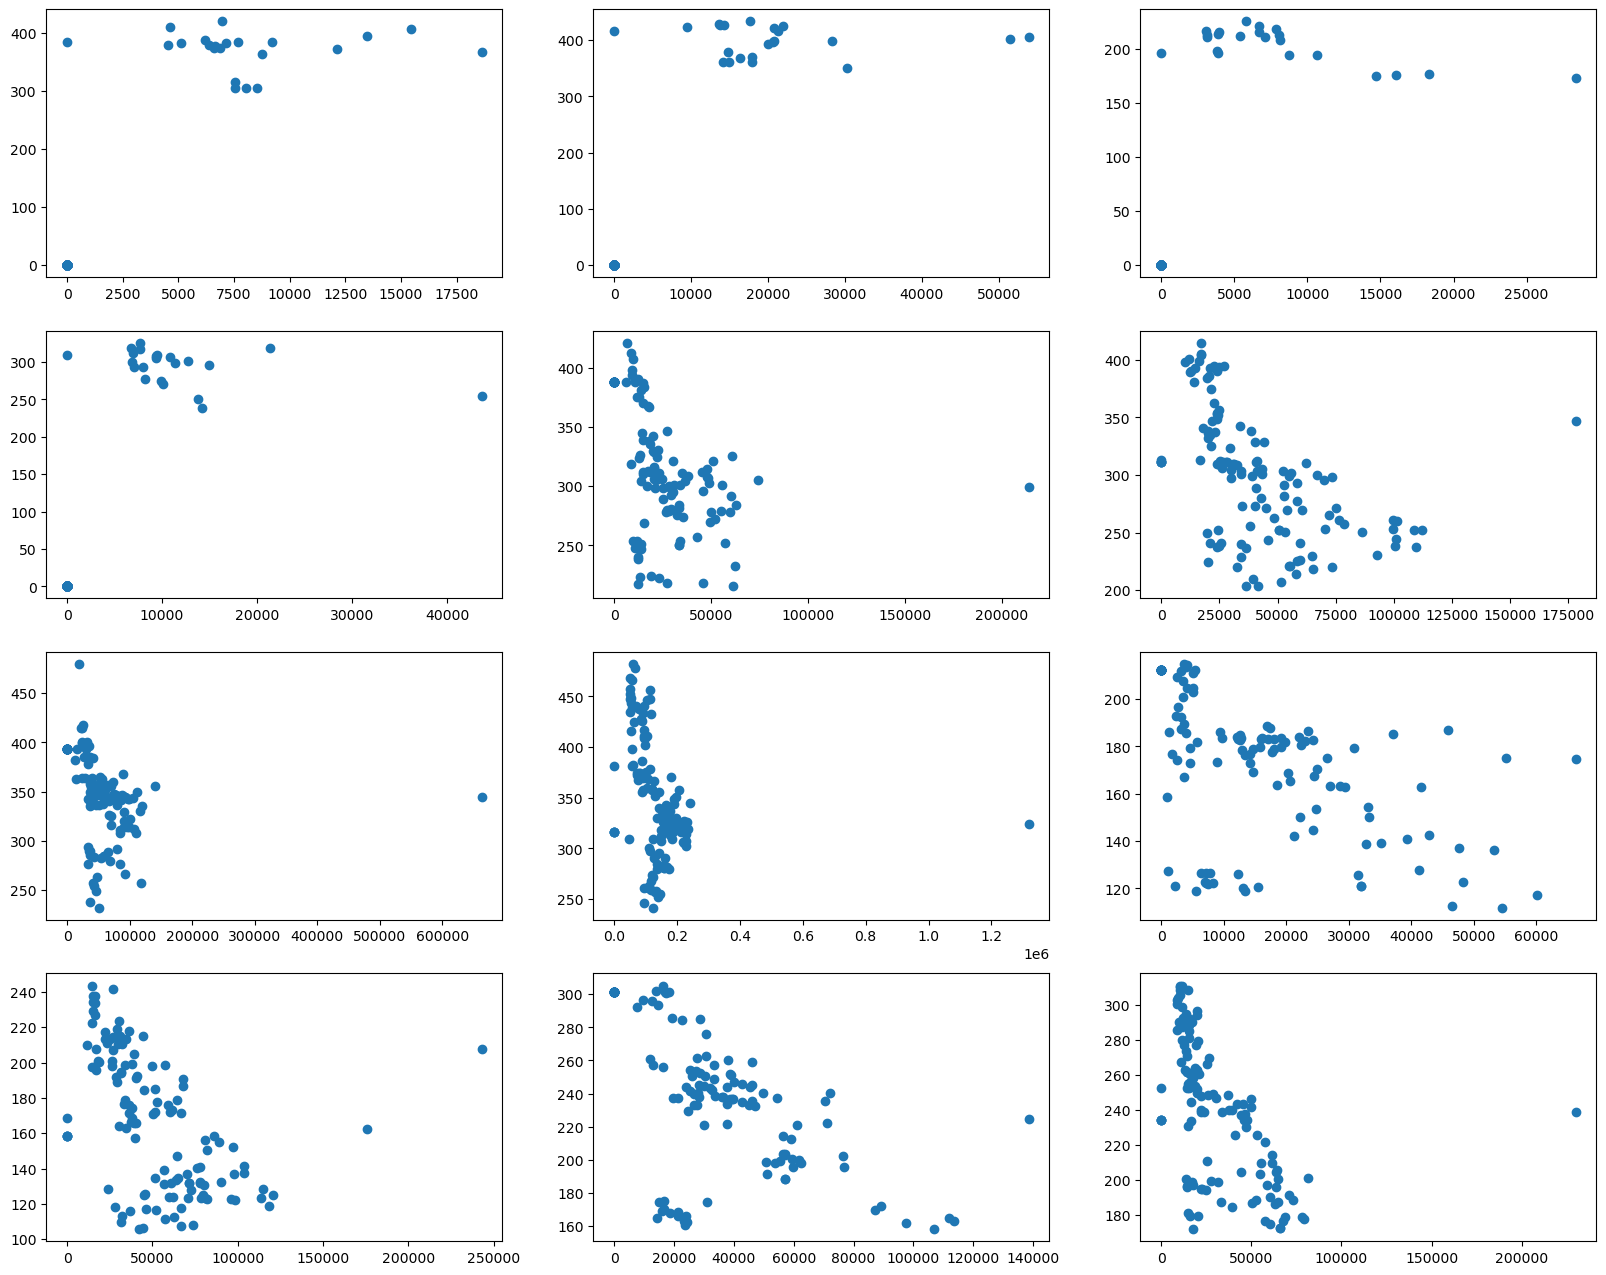

In [113]:
fig,axs = plt.subplots(4,3,figsize=(20,16))
for k,ax in enumerate(axs.ravel()):
    tmp_x = df_set[df_set.prd_agg==prd_agg[k]].gv_sum
    tmp_y = df_set[df_set.prd_agg==prd_agg[k]].avg_price_mean
    ax.scatter(tmp_x,tmp_y)
    del tmp_x,tmp_y

## Interaction terms from decision tree

In [112]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

In [113]:
dct = DecisionTreeRegressor(max_depth=5)

In [114]:
X = tmp_df_set.iloc[:,3:-1] # exclude [prdct_title, ord_rev_sum, ord_qty_sum, year_week]
y = tmp_df_set.ord_rev_sum

In [107]:
dct.fit(X,y)

DecisionTreeRegressor(max_depth=5)

In [108]:
dct.feature_importances_

array([0.1597937 , 0.02400474, 0.55743868, 0.00759291, 0.20801249,
       0.04221419, 0.        , 0.        , 0.        , 0.00094329])

In [109]:
# Training score
dct.score(X,y)

0.983127115826068

In [110]:
tree_rep = tree.export_text(dct)
print(tree_rep)

|--- feature_2 <= 40.00
|   |--- feature_4 <= 34038.50
|   |   |--- feature_2 <= 37.00
|   |   |   |--- feature_1 <= 309.50
|   |   |   |   |--- feature_5 <= 0.06
|   |   |   |   |   |--- value: [188434.24]
|   |   |   |   |--- feature_5 >  0.06
|   |   |   |   |   |--- value: [221117.36]
|   |   |   |--- feature_1 >  309.50
|   |   |   |   |--- value: [134288.05]
|   |   |--- feature_2 >  37.00
|   |   |   |--- value: [319964.15]
|   |--- feature_4 >  34038.50
|   |   |--- feature_1 <= 232.50
|   |   |   |--- value: [672347.42]
|   |   |--- feature_1 >  232.50
|   |   |   |--- feature_9 <= 0.22
|   |   |   |   |--- value: [452395.70]
|   |   |   |--- feature_9 >  0.22
|   |   |   |   |--- feature_4 <= 53905.50
|   |   |   |   |   |--- value: [506311.59]
|   |   |   |   |--- feature_4 >  53905.50
|   |   |   |   |   |--- value: [484669.22]
|--- feature_2 >  40.00
|   |--- feature_0 <= 154.62
|   |   |--- feature_4 <= 43941.50
|   |   |   |--- feature_2 <= 50.50
|   |   |   |   |--- fea

/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


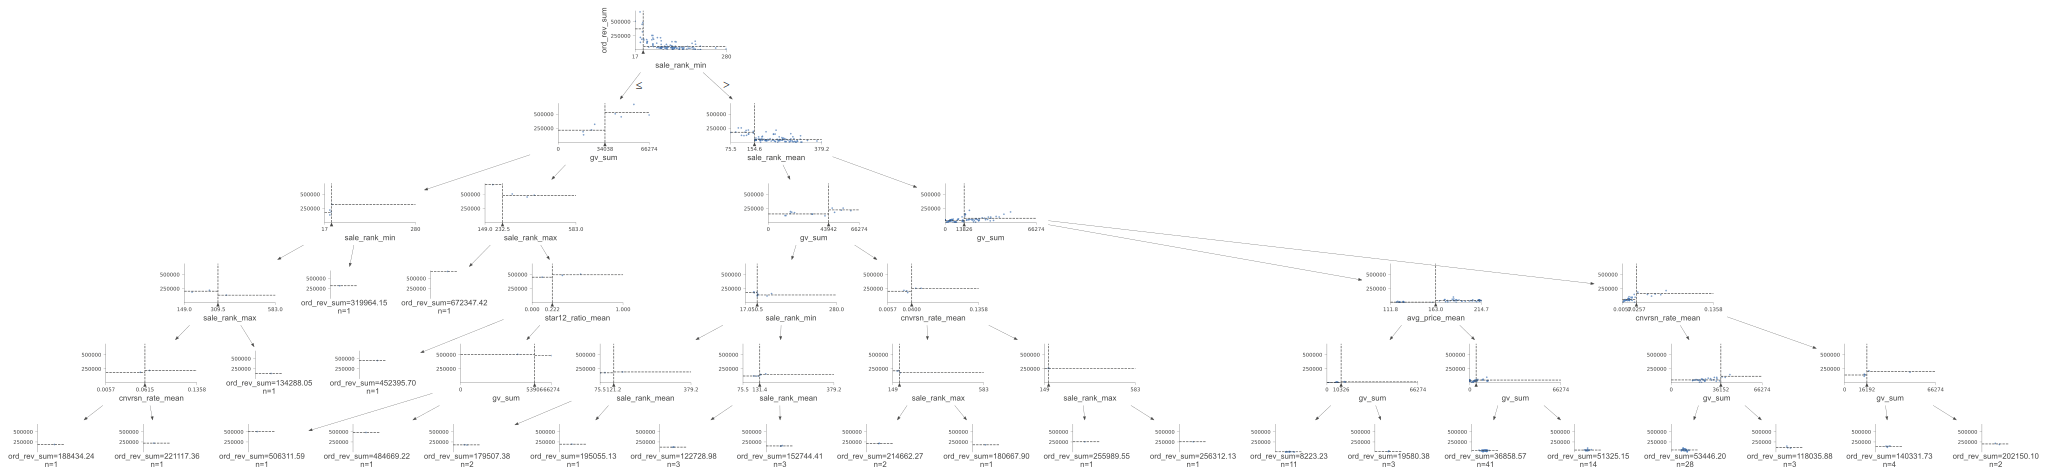

In [111]:
from dtreeviz.trees import dtreeviz 
viz = dtreeviz(dct, X, y,
                target_name="ord_rev_sum",
                feature_names=tmp_df_set.columns[3:-1].tolist())
viz

## interaction terms from GA2M

Microsoft EBM package (https://interpret.ml/docs/ebm.html)

In [133]:
from interpret import set_visualize_provider, show
from interpret.provider import InlineProvider
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.model_selection import train_test_split

set_visualize_provider(InlineProvider())

In [137]:
X = tmp_df_set.iloc[:,3:-1] # exclude [prdct_title, ord_rev_sum, ord_qty_sum, year_week]
y = tmp_df_set.ord_rev_sum

seed=42
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)

ebm = ExplainableBoostingRegressor(random_state=seed)
ebm.fit(X, y)

ebm_global = ebm.explain_global()
show(ebm_global)

#ebm_local = ebm.explain_local(X_test[:5], y_test[:5])
#show(ebm_local)

In [141]:
ebm.feature_importances_

[9781.950668276631,
 5607.069255515377,
 10580.931087953693,
 6568.614038143268,
 15032.779324728286,
 8641.018641049712,
 3210.1164451917803,
 7301.225022708347,
 6826.097000708205,
 4357.795906762505,
 1512.8295502252913,
 2766.610334031402,
 1374.2057230679575,
 1159.2490626817296,
 1429.1308092693216,
 2100.187225521613,
 1544.320315155685,
 1478.9035212057893,
 1231.6150562411563,
 1184.3460500649444]

In [154]:
pd.DataFrame(np.round(ebm.feature_importances_,0),index=ebm.feature_names)

,0
sale_rank_mean,9782.0
sale_rank_max,5607.0
sale_rank_min,10581.0
avg_price_mean,6569.0
gv_sum,15033.0
cnvrsn_rate_mean,8641.0
rep_oos_mean,3210.0
rvw_cnt_sum,7301.0
star12_cnt_sum,6826.0
star12_ratio_mean,4358.0


### Any interactions?

In [155]:
[x for x in ebm.feature_names if x.__contains__(' x ')]

['sale_rank_min x gv_sum',
 'gv_sum x cnvrsn_rate_mean',
 'gv_sum x rvw_cnt_sum',
 'avg_price_mean x gv_sum',
 'gv_sum x rep_oos_mean',
 'cnvrsn_rate_mean x rvw_cnt_sum',
 'gv_sum x star12_ratio_mean',
 'sale_rank_mean x gv_sum',
 'sale_rank_max x gv_sum',
 'sale_rank_min x rep_oos_mean']